# UKR+COVID NM Aug Checkpoint Trajectory

Visualizes `merged_ukr_rus_covid_nm_aug_15_06_2026_15_22_07` checkpoint evals on `covid_political`, classification (`pl`), 3-shot, test split.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

CSV_CANDIDATES = [
    Path("eval_results.csv"),
    Path("scripts/plotting/covid_political_pl_trajectory_aug/eval_results.csv"),
    Path.home() / "Downloads" / "ukr_rus_covid_nm_aug_15_06_2026_15_22_07.csv",
]
CSV_PATH = next((path for path in CSV_CANDIDATES if path.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError("Could not find eval_results.csv or the Downloads CSV")
CSV_PATH = CSV_PATH.resolve()

SPLIT = "test"
DATASET = "covid_political"
TASK = "pl"
SHOTS = 3
METRICS = ["accuracy", "f1", "roc_auc"]
METRIC_LABELS = {
    "accuracy": "Accuracy",
    "f1": "F1",
    "roc_auc": "ROC-AUC",
}
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

In [2]:
raw = pd.read_csv(CSV_PATH)

required = {"model", "dataset", "task", "shots", "split", *METRICS}
missing = required - set(raw.columns)
if missing:
    raise ValueError(f"CSV is missing required columns: {sorted(missing)}")

df = raw.copy()
df["shots"] = pd.to_numeric(df["shots"], errors="raise").astype(int)
for col in METRICS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["step"] = df["model"].str.extract(r"_step([0-9]+)$", expand=False)
if df["step"].isna().any():
    bad = df.loc[df["step"].isna(), "model"].tolist()
    raise ValueError(f"Could not parse checkpoint step from model names: {bad}")
df["step"] = df["step"].astype(int)

df = df[
    (df["dataset"] == DATASET)
    & (df["task"] == TASK)
    & (df["shots"] == SHOTS)
    & (df["split"] == SPLIT)
].sort_values("step")

if df.empty:
    raise ValueError("No rows left after filtering to covid_political/pl/3-shot/test")

present_steps = df["step"].tolist()
print(f"reading {CSV_PATH}")
print(f"rows: {len(df)}")
print(f"steps: {present_steps}")
display(df[["step", *METRICS, "run_name"]])

reading /Users/philipp/projects/gfm/prodigy/scripts/plotting/covid_political_pl_trajectory_aug/eval_results.csv
rows: 8
steps: [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000]


,step,accuracy,f1,roc_auc,run_name
0,1000,0.761333,0.763852,0.830437,eval_merged_ukr_rus_covid_nm_aug_15_06_2026_15...
1,2000,0.770083,0.768443,0.839661,eval_merged_ukr_rus_covid_nm_aug_15_06_2026_15...
2,3000,0.772083,0.769645,0.846532,eval_merged_ukr_rus_covid_nm_aug_15_06_2026_15...
3,4000,0.764917,0.774266,0.844283,eval_merged_ukr_rus_covid_nm_aug_15_06_2026_15...
4,5000,0.766000,0.773877,0.842676,eval_merged_ukr_rus_covid_nm_aug_15_06_2026_15...
5,6000,0.764417,0.774399,0.845954,eval_merged_ukr_rus_covid_nm_aug_15_06_2026_15...
6,7000,0.759167,0.771794,0.838386,eval_merged_ukr_rus_covid_nm_aug_15_06_2026_15...
7,8000,0.758917,0.767873,0.834594,eval_merged_ukr_rus_covid_nm_aug_15_06_2026_15...


In [3]:
best_rows = []
for metric in METRICS:
    idx = df[metric].idxmax()
    row = df.loc[idx, ["step", metric]].copy()
    best_rows.append({
        "metric": METRIC_LABELS[metric],
        "best_step": int(row["step"]),
        "best_value": float(row[metric]),
    })

best_table = pd.DataFrame(best_rows)
display(best_table.style.format({"best_value": "{:.4f}"}))

,metric,best_step,best_value
0,Accuracy,3000,0.7721
1,F1,6000,0.7744
2,ROC-AUC,3000,0.8465


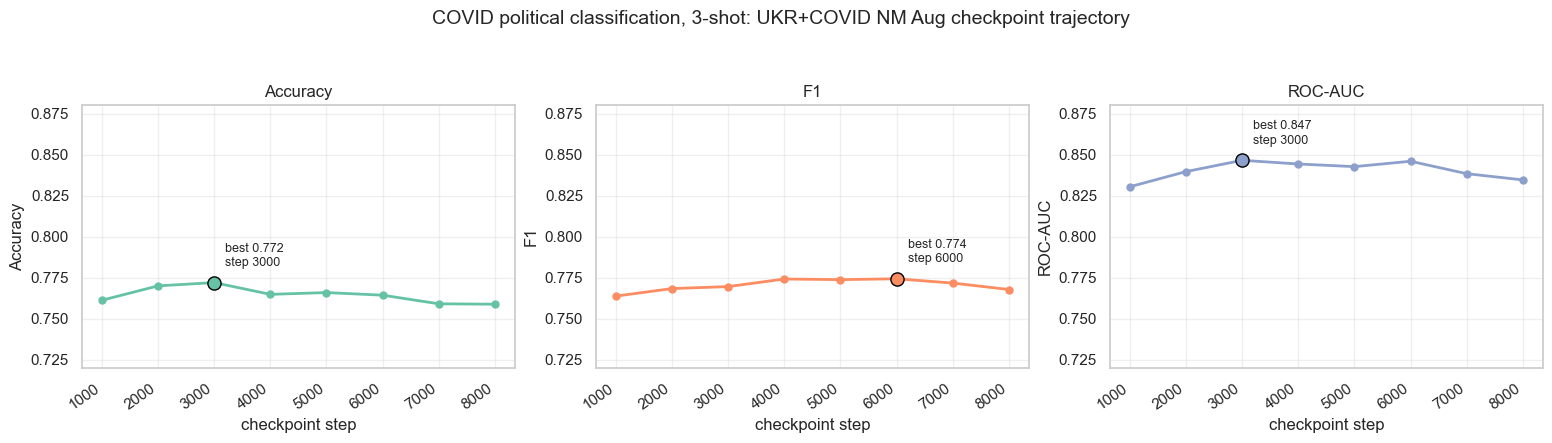

In [4]:
palette = dict(zip(METRICS, sns.color_palette("Set2", n_colors=len(METRICS))))

fig, axes = plt.subplots(1, len(METRICS), figsize=(5.2 * len(METRICS), 4.2), sharex=True)
if len(METRICS) == 1:
    axes = [axes]

for ax, metric in zip(axes, METRICS):
    line = df.sort_values("step")
    ax.plot(
        line["step"],
        line[metric],
        marker="o",
        linewidth=2,
        markersize=5,
        color=palette[metric],
    )
    best_idx = line[metric].idxmax()
    best = line.loc[best_idx]
    ax.scatter([best["step"]], [best[metric]], s=90, color=palette[metric], edgecolor="black", zorder=3)
    ax.annotate(
        f"best {best[metric]:.3f}\nstep {int(best['step'])}",
        xy=(best["step"], best[metric]),
        xytext=(8, 12),
        textcoords="offset points",
        fontsize=9,
    )
    ax.set_title(METRIC_LABELS[metric])
    ax.set_xlabel("checkpoint step")
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.set_ylim(0.72, 0.88)
    ax.set_xticks(present_steps)
    ax.set_xticklabels([str(step) for step in present_steps], rotation=35, ha="right")
    ax.grid(True, alpha=0.3)

fig.suptitle("COVID political classification, 3-shot: UKR+COVID NM Aug checkpoint trajectory", y=1.05, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "ukr_rus_covid_nm_aug_trajectory_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

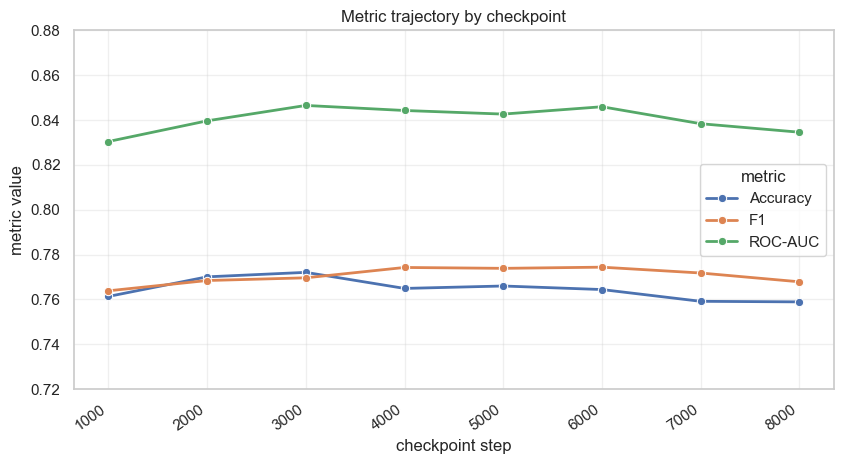

In [5]:
long = df.melt(
    id_vars=["step"],
    value_vars=METRICS,
    var_name="metric",
    value_name="value",
)
long["metric_label"] = long["metric"].map(METRIC_LABELS)

fig, ax = plt.subplots(figsize=(8.6, 4.8))
sns.lineplot(
    data=long,
    x="step",
    y="value",
    hue="metric_label",
    marker="o",
    linewidth=2,
    ax=ax,
)
ax.set_title("Metric trajectory by checkpoint")
ax.set_xlabel("checkpoint step")
ax.set_ylabel("metric value")
ax.set_ylim(0.72, 0.88)
ax.set_xticks(present_steps)
ax.set_xticklabels([str(step) for step in present_steps], rotation=35, ha="right")
ax.legend(title="metric")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "ukr_rus_covid_nm_aug_trajectory_overlay.png", dpi=200, bbox_inches="tight")
plt.show()

In [6]:
wide = df.set_index("step")[METRICS].sort_index()
delta = wide.diff().rename(columns={metric: f"delta_{metric}" for metric in METRICS})
inspect_table = pd.concat([wide, delta], axis=1)
display(inspect_table.style.format("{:.4f}").background_gradient(cmap="YlGnBu", subset=METRICS))

,accuracy,f1,roc_auc,delta_accuracy,delta_f1,delta_roc_auc
step,,,,,,
1000,0.7613,0.7639,0.8304,nan,nan,nan
2000,0.7701,0.7684,0.8397,0.0088,0.0046,0.0092
3000,0.7721,0.7696,0.8465,0.0020,0.0012,0.0069
4000,0.7649,0.7743,0.8443,-0.0072,0.0046,-0.0022
5000,0.7660,0.7739,0.8427,0.0011,-0.0004,-0.0016
6000,0.7644,0.7744,0.8460,-0.0016,0.0005,0.0033
7000,0.7592,0.7718,0.8384,-0.0052,-0.0026,-0.0076
8000,0.7589,0.7679,0.8346,-0.0002,-0.0039,-0.0038
